# 04 - Aplicação estratégica

Converte a saída do modelo nas cinco perguntas de negócio do enunciado. A regra da
seção: **cada resposta vem acompanhada do que ela não autoriza concluir.** Um
ranking que não diz onde erra não serve para decidir gasto público.

| # | Pergunta do enunciado | Etapa |
|---|---|---|
| 1 e 5 | Quais fatores mais impactam? Quais variáveis mais influenciam? | 2 |
| 2 | Quais municípios apresentam maior risco educacional? | 3 |
| 3 | Quais regiões possuem padrões semelhantes? | 4 |
| 4 | Como prever municípios que podem não atingir metas futuras? | 5 |

In [1]:
# ==== 1. PREPARAÇÃO ====
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling import FEATURES, TARGET, carregar_dataset
from src.evaluation import (
    cobertura_por_limiar, importancia_nativa, importancia_por_permutacao,
    perfil_por_regiao, ranking_de_risco,
)
from src.visualization import NEGATIVO, POSITIVO, SERIE, aplicar_estilo, limpar, salvar

aplicar_estilo()
IMAGENS = ROOT / "images"

df = carregar_dataset()
teste = df[df["ano"] == 2024].copy()
modelo = joblib.load(ROOT / "reports" / "modelo_final.joblib")

ranking = ranking_de_risco(modelo, teste[FEATURES], teste, observado=teste[TARGET])
print(f"Municipios avaliados no ciclo de 2024: {len(ranking):,}")
display(ranking.head(10).round(4))

Municipios avaliados no ciclo de 2024: 5,352


,id_municipio,ano,sigla_uf,regiao,prob_atingir_meta,prob_risco,atingiu_observado
0,1712702,2024,TO,Norte,0.0,1.0,0
1,1707702,2024,TO,Norte,0.0,1.0,0
2,1711951,2024,TO,Norte,0.0,1.0,0
3,2203354,2024,PI,Nordeste,0.0,1.0,0
4,2800209,2024,SE,Nordeste,0.0,1.0,0
5,1709807,2024,TO,Norte,0.0,1.0,0
6,2919900,2024,BA,Nordeste,0.0,1.0,0
7,1710706,2024,TO,Norte,0.0,1.0,0
8,1703008,2024,TO,Norte,0.0,1.0,0
9,2805109,2024,SE,Nordeste,0.0,1.0,0


## Etapa 2 - Quais fatores mais impactam a alfabetização? (perguntas 1 e 5)

In [2]:
# ==== 2. FATORES DE MAIOR INFLUÊNCIA ====
coeficientes = importancia_nativa(modelo)
permutacao = importancia_por_permutacao(modelo, teste[FEATURES], teste[TARGET])
display(coeficientes.head(10).round(3))
display(permutacao.round(4))

,variavel,coeficiente,importancia
0,media_portugues,5.416,5.416
1,sigla_uf_RN,2.570,2.570
2,sigla_uf_PA,2.161,2.161
3,sigla_uf_GO,1.970,1.970
4,sigla_uf_MS,-1.795,1.795
5,regiao_Sul,1.659,1.659
6,sigla_uf_TO,-1.639,1.639
7,sigla_uf_AM,1.448,1.448
8,sigla_uf_RO,-1.379,1.379
9,sigla_uf_ES,1.292,1.292


,variavel,queda_roc_auc,desvio
0,media_portugues,0.3815,0.0070
1,meta_2025,0.0059,0.0001
2,meta_uf_2025,-0.0016,0.0008
3,taxa_media_uf_loo,-0.0063,0.0017
4,sigla_uf,-0.0133,0.0014
5,regiao,-0.0276,0.0013


**Resposta.** Dentro do modelo, `media_portugues` é o fator dominante: coeficiente
padronizado **5,42**, contra 2,57 da dummy seguinte, e **0,38 de queda de ROC-AUC**
quando embaralhada, contra 0,006 da segunda colocada — duas ordens de grandeza
de diferença.

**O que isso não autoriza.** A nota de Português e a taxa de alfabetização medem o
mesmo desempenho no mesmo ciclo (correlação 0,93, notebook 02). A associação é forte
porque as duas medidas são próximas, não porque exista um mecanismo causal
identificado. Nenhuma das variáveis do modelo é uma alavanca de política acionável:
não há formação docente, investimento, infraestrutura ou renda na base.

A permutation importance ainda mostra que `sigla_uf`, `regiao`, `meta_uf_2025` e
`taxa_media_uf_loo` têm contribuição **negativa** no ciclo seguinte — o padrão
territorial aprendido em 2023 não se repete em 2024.

## Etapa 3 - Quais municípios apresentam maior risco? (pergunta 2)

,id_municipio,ano,sigla_uf,regiao,prob_atingir_meta,prob_risco,atingiu_observado
0,1712702,2024,TO,Norte,0.0,1.0,0
1,1707702,2024,TO,Norte,0.0,1.0,0
2,1711951,2024,TO,Norte,0.0,1.0,0
3,2203354,2024,PI,Nordeste,0.0,1.0,0
4,2800209,2024,SE,Nordeste,0.0,1.0,0
5,1709807,2024,TO,Norte,0.0,1.0,0
6,2919900,2024,BA,Nordeste,0.0,1.0,0
7,1710706,2024,TO,Norte,0.0,1.0,0
8,1703008,2024,TO,Norte,0.0,1.0,0
9,2805109,2024,SE,Nordeste,0.0,1.0,0


,limiar,municipios_sinalizados,cobertura_do_risco,precisao_do_alerta
0,0.5,4039,0.9168,0.6878
1,0.7,3680,0.8667,0.7136
2,0.8,3472,0.8350,0.7287
3,0.9,3136,0.7825,0.7561


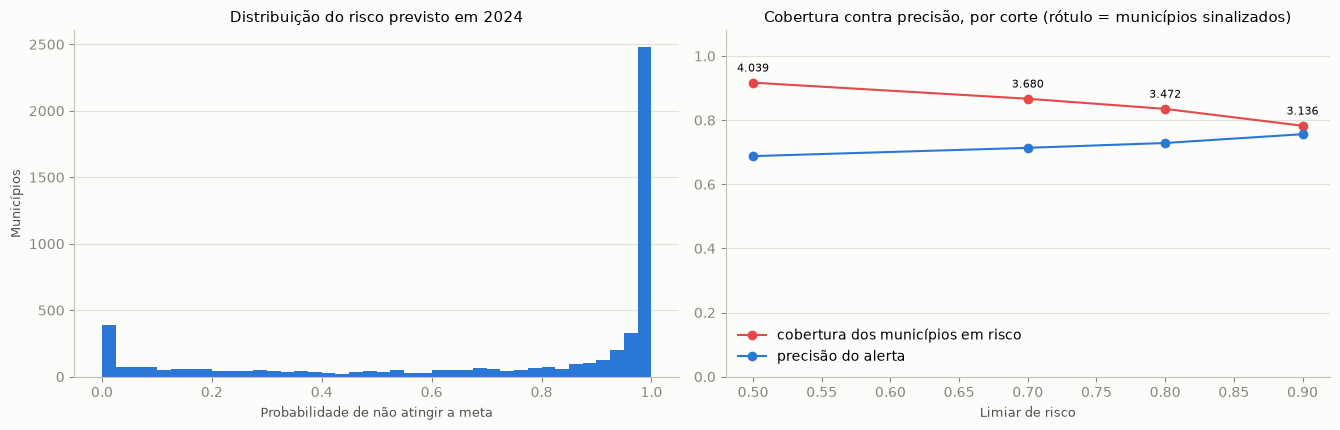

In [3]:
# ==== 3. RANKING DE RISCO E LIMIAR DE PRIORIZAÇÃO ====
ranking.to_csv(ROOT / "reports" / "ranking_risco_2024.csv", index=False)
display(ranking.head(15).round(4))

cobertura = cobertura_por_limiar(ranking)
display(cobertura)

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.4))
eixos[0].hist(ranking["prob_risco"], bins=40, color=SERIE[0])
eixos[0].set(title="Distribuição do risco previsto em 2024",
             xlabel="Probabilidade de não atingir a meta", ylabel="Municípios")

eixos[1].plot(cobertura["limiar"], cobertura["cobertura_do_risco"], "o-",
              color=NEGATIVO, label="cobertura dos municípios em risco")
eixos[1].plot(cobertura["limiar"], cobertura["precisao_do_alerta"], "o-",
              color=SERIE[0], label="precisão do alerta")
for _, linha in cobertura.iterrows():
    eixos[1].annotate(f"{int(linha['municipios_sinalizados']):,}".replace(",", "."),
                      (linha["limiar"], linha["cobertura_do_risco"]),
                      textcoords="offset points", xytext=(0, 8),
                      ha="center", fontsize=8)
eixos[1].set(title="Cobertura contra precisão, por corte (rótulo = municípios sinalizados)",
             xlabel="Limiar de risco", ylim=(0, 1.08))
eixos[1].legend(loc="lower left")
for eixo in eixos:
    limpar(eixo)
plt.tight_layout()
salvar(fig, "04_ranking_risco", IMAGENS)
plt.show()

**Resposta.** O ranking completo está em `reports/ranking_risco_2024.csv`, ordenado
do maior para o menor risco. O corte é uma decisão de gestão, não do modelo: no
limiar de 0,5 são sinalizados **4.039 municípios**, cobrindo **91,7%** dos que de
fato não atingiram a meta, com precisão de **68,8%**. Subir o corte para 0,9 reduz a lista para
**3.136** municípios e eleva a precisão a 75,6%, ao custo de perder 14 pontos de
cobertura.

**O que isso não autoriza.** A lista é uma ordem de investigação. As probabilidades
estão mal calibradas para 2024 (desvio de 0,193, notebook 03), então o **valor**
do escore não deve ser publicado como "chance real" — só a posição relativa é útil.

## Etapa 4 - Quais regiões possuem padrões semelhantes? (pergunta 3)

,regiao,municipios,risco_medio_previsto,risco_observado,diferenca
0,Norte,425,0.9414,0.7459,0.1955
1,Nordeste,1756,0.7931,0.6185,0.1747
2,Sudeste,1614,0.7929,0.4294,0.3635
3,Centro-Oeste,464,0.6369,0.3578,0.2791
4,Sul,1093,0.5462,0.7027,-0.1564


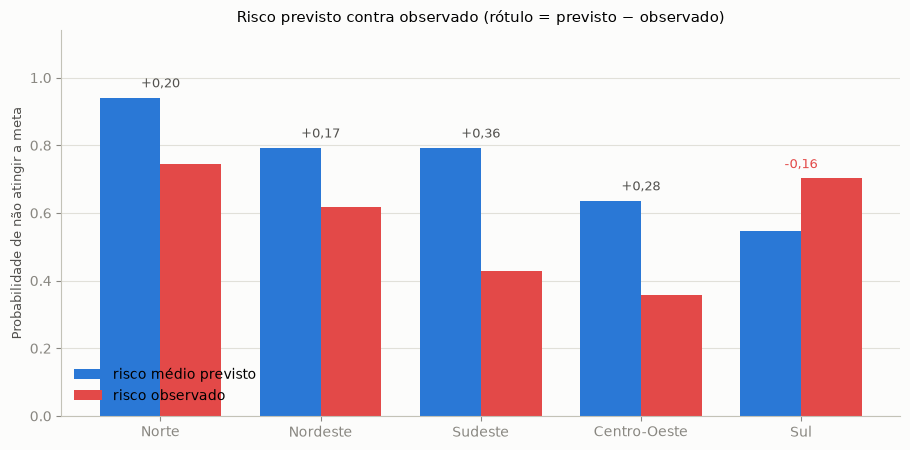

In [4]:
# ==== 4. PADRÕES REGIONAIS: PREVISTO CONTRA OBSERVADO ====
perfil = perfil_por_regiao(ranking)
display(perfil.round(4))

posicao = np.arange(len(perfil))
largura = 0.38
fig, eixo = plt.subplots(figsize=(9.2, 4.6))
eixo.bar(posicao - largura / 2, perfil["risco_medio_previsto"], largura,
         label="risco médio previsto", color=SERIE[0])
eixo.bar(posicao + largura / 2, perfil["risco_observado"], largura,
         label="risco observado", color=NEGATIVO)
# O sinal importa: positivo = o modelo superestima o risco; negativo = subestima.
for i, diferenca in enumerate(perfil["diferenca"]):
    rotulo = f"{diferenca:+.2f}".replace(".", ",")
    eixo.annotate(rotulo, (i, max(perfil["risco_medio_previsto"][i],
                                  perfil["risco_observado"][i]) + 0.03),
                  ha="center", fontsize=9,
                  color=NEGATIVO if diferenca < 0 else "#52514e")
eixo.set(xticks=posicao, ylim=(0, 1.14), ylabel="Probabilidade de não atingir a meta",
         title="Risco previsto contra observado (rótulo = previsto − observado)")
eixo.set_xticklabels(perfil["regiao"])
eixo.legend(loc="lower left")
limpar(eixo)
plt.tight_layout()
salvar(fig, "04_risco_por_regiao", IMAGENS)
plt.show()

**Resposta.** Pelo escore do modelo, **Nordeste e Sudeste formam um par**: risco médio
previsto praticamente idêntico, **79,3%** nos dois. Norte aparece isolado no topo
(94,1%) e Sul no piso (54,6%).

**O que isso não autoriza — e é o achado mais importante desta etapa.** Confrontado
com o resultado observado de 2024, o agrupamento se desfaz. O risco realmente
observado no Sudeste é de **42,9%**, contra **61,9%** no Nordeste: as duas regiões
com escore idêntico estão a 19 pontos de distância na realidade. O modelo superestima
o risco do Sudeste em **0,36** — ele reproduz a geografia de 2023 e não acompanhou a
melhora da região.

O caso do **Sul** é o oposto e o mais grave: é a única região cujo risco o modelo
**subestima** (previsto 54,6%, observado 70,3%, diferença de −0,16). Coerente com a
EDA, o Sul foi a única região a piorar entre os ciclos — e é justamente onde o modelo
sinaliza menos risco.

A conclusão honesta é que **este modelo não responde bem à pergunta 3**. Agrupar
regiões por escore previsto reproduz a geografia do ano de treino, não a do ano
avaliado. Responder isso corretamente exigiria recalibração por ciclo ou variáveis de
contexto que a base atual não tem.

## Etapa 5 - Como prever municípios que não atingirão metas futuras? (pergunta 4)

In [5]:
# ==== 5. O QUE A BASE ATUAL PERMITE, E O QUE NÃO PERMITE ====
resumo = pd.DataFrame([
    {"requisito": "features anteriores ao ciclo previsto",
     "situacao": "NAO", "detalhe": "media_portugues e taxa_media_uf_loo sao do proprio ciclo"},
    {"requisito": "ciclo de avaliacao nunca visto",
     "situacao": "SIM", "detalhe": "2024 nao participou do ajuste nem do tuning"},
    {"requisito": "ciclos suficientes para validacao temporal repetida",
     "situacao": "NAO", "detalhe": "apenas 2023 e 2024; uma unica transicao"},
    {"requisito": "estabilidade da prevalencia entre ciclos",
     "situacao": "NAO", "detalhe": "18,1% em 2023 contra 43,4% em 2024"},
])
display(resumo)

print("Municipios sinalizados por corte de risco:")
for limiar in (0.50, 0.70, 0.80, 0.90):
    quantidade = int((ranking["prob_risco"] >= limiar).sum())
    print(f"  risco >= {limiar:.0%}: {quantidade:,} municipios "
          f"({quantidade / len(ranking):.1%} da base)")

,requisito,situacao,detalhe
0,features anteriores ao ciclo previsto,NAO,media_portugues e taxa_media_uf_loo sao do pro...
1,ciclo de avaliacao nunca visto,SIM,2024 nao participou do ajuste nem do tuning
2,ciclos suficientes para validacao temporal rep...,NAO,apenas 2023 e 2024; uma unica transicao
3,estabilidade da prevalencia entre ciclos,NAO,"18,1% em 2023 contra 43,4% em 2024"


Municipios sinalizados por corte de risco:
  risco >= 50%: 4,039 municipios (75.5% da base)
  risco >= 70%: 3,680 municipios (68.8% da base)
  risco >= 80%: 3,472 municipios (64.9% da base)
  risco >= 90%: 3,136 municipios (58.6% da base)


**Resposta.** Com rigor: **a implementação atual não responde a essa pergunta.** Ela
classifica um ciclo já avaliado (*nowcast*), porque duas das seis variáveis são
contemporâneas ao resultado. O que ela entrega é uma priorização do ciclo corrente,
útil enquanto o resultado oficial não é consolidado.

Para uma previsão *ex ante* legítima seriam necessários: features exclusivamente
defasadas, pelo menos três ciclos comparáveis e validação em um ciclo posterior
nunca usado. Os dois primeiros requisitos falham hoje.

## Síntese executiva

- **Use** o ranking como ordem de triagem e alocação de atenção técnica.
- **Escolha o corte pela capacidade real** de atendimento, não por 0,5.
- **Não publique** o valor da probabilidade: ele está descalibrado para 2024.
- **Não trate** semelhança de escore regional como semelhança educacional.
- **Não leia** os fatores como alavancas causais — a base não tem variáveis de
  política pública.
- **Próximo passo:** um terceiro ciclo e indicadores anteriores à avaliação, que é
  o que transformaria classificação em previsão.